# Smart Finance - Análise de Comportamento Financeiro

# Treinamento dos Modelos

## Objetivo

Treinar os dois modelos de Machine Learning utilizados no projeto.

Modelo 1

- Classificação automática das transações

Modelo 2

- Classificação do perfil financeiro


In [1]:
# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS - MODELO 1
# ==========================================================

import pandas as pd

import joblib

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Hackatona G9 Finance AI/data"
BASE_MODELS = "/content/drive/MyDrive/Hackatona G9 Finance AI/models"

Mounted at /content/drive


In [3]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

#dataset_categoria = pd.read_csv(

#    "data/model/dataset_modelo_categoria.csv"

#)

In [4]:
# ==========================================================
# LEITURA DO DATASET (colab)
# ==========================================================

dataset_categoria = pd.read_csv(
    f"{BASE}/model/dataset_modelo_categoria.csv"
)

In [5]:
# ==========================================================
# VARIÁVEIS
# ==========================================================

X_texto = dataset_categoria["descricao_transacao"]

X_valor = dataset_categoria["valor_transacao"]

y = dataset_categoria["categoria"]

In [6]:
# ==========================================================
# TF-IDF
# ==========================================================

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words=None

)

X_texto = tfidf.fit_transform(

    X_texto

)

In [7]:
# ==========================================================
# CONCATENAÇÃO DA FEATURE NUMÉRICA
# ==========================================================

from scipy.sparse import hstack

X = hstack(

    [

        X_texto,

        X_valor.values.reshape(-1,1)

    ]

)

In [8]:
# ==========================================================
# DIVISÃO TREINO / TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [9]:
# ==========================================================
# TREINAMENTO
# ==========================================================

modelo_categoria = MultinomialNB()

modelo_categoria.fit(

    X_train,

    y_train

)

MultinomialNB()

In [10]:
# ==========================================================
# PREDIÇÃO
# ==========================================================

predicoes = modelo_categoria.predict(

    X_test

)

In [11]:
# ==========================================================
# MÉTRICAS DE AVALIAÇÃO
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, predicoes)

precision = precision_score(
    y_test,
    predicoes,
    average="macro"
)

recall = recall_score(
    y_test,
    predicoes,
    average="macro"
)

f1 = f1_score(
    y_test,
    predicoes,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9838
Precision: 0.9860
Recall   : 0.9826
F1-Score : 0.9836


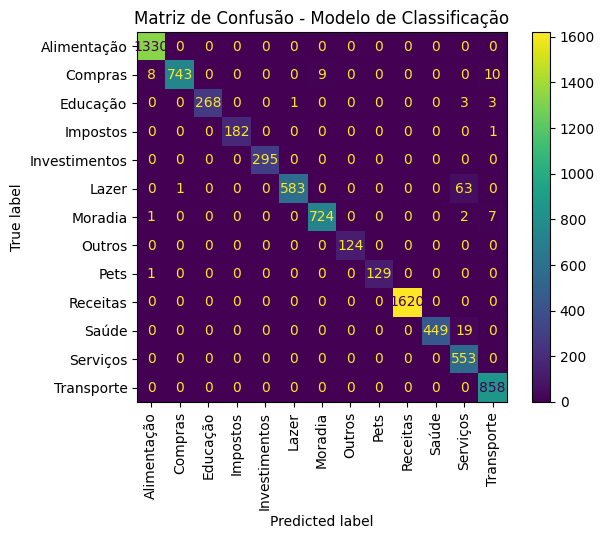

In [12]:
# ==========================================================
# MATRIZ DE CONFUSÃO
# ==========================================================

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicoes,
    xticks_rotation=90
)

plt.title("Matriz de Confusão - Modelo de Classificação")

plt.show()

In [13]:
# ==========================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ==========================================================

print(

classification_report(

    y_test,

    predicoes,

    digits=4

)

)

               precision    recall  f1-score   support

  Alimentação     0.9925    1.0000    0.9963      1330
      Compras     0.9987    0.9649    0.9815       770
     Educação     1.0000    0.9745    0.9871       275
     Impostos     1.0000    0.9945    0.9973       183
Investimentos     1.0000    1.0000    1.0000       295
        Lazer     0.9983    0.9011    0.9472       647
      Moradia     0.9877    0.9864    0.9870       734
       Outros     1.0000    1.0000    1.0000       124
         Pets     1.0000    0.9923    0.9961       130
     Receitas     1.0000    1.0000    1.0000      1620
        Saúde     1.0000    0.9594    0.9793       468
     Serviços     0.8641    1.0000    0.9271       553
   Transporte     0.9761    1.0000    0.9879       858

     accuracy                         0.9838      7987
    macro avg     0.9860    0.9826    0.9836      7987
 weighted avg     0.9854    0.9838    0.9840      7987



In [14]:
# ==========================================================
# SALVANDO MODELO 1
# ==========================================================

import os

BASE_MODELS = "/content/drive/MyDrive/Hackatona G9 Finance AI/models"
os.makedirs(BASE_MODELS, exist_ok=True)

In [15]:
joblib.dump(
    modelo_categoria,
    f"{BASE_MODELS}/modelo_categoria.joblib"
)

joblib.dump(
    tfidf,
    f"{BASE_MODELS}/tfidf.joblib"
)

print(

"Modelo de classificação treinado com sucesso."

)

Modelo de classificação treinado com sucesso.


In [16]:
# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

scores = cross_val_score(

    modelo_categoria,

    X,

    y,

    cv=cv,

    scoring="f1_macro"

)

print("========== Validação Cruzada ==========")

print(f"F1 Macro por Fold: {scores}")

print(f"F1 Macro Médio: {scores.mean():.4f}")

print(f"Desvio Padrão: {scores.std():.4f}")

========== Validação Cruzada ==========
F1 Macro por Fold: [0.98301676 0.98090856 0.98180682 0.97946777 0.98012965]
F1 Macro Médio: 0.9811
Desvio Padrão: 0.0012


# Conclusão

## Objetivo alcançado

Neste notebook foram treinados e avaliados os dois modelos de Machine Learning responsáveis pelo núcleo inteligente da aplicação.

### Modelo 1 — Classificação de Transações

Foi desenvolvido um modelo baseado em **TF-IDF** e **Multinomial Naive Bayes**, responsável por classificar automaticamente descrições de transações em suas respectivas categorias financeiras.

Foram realizadas:

- Vetorização textual utilizando TF-IDF;
- Divisão entre treino e teste;
- Treinamento do modelo;
- Avaliação por Accuracy, Precision, Recall e F1-Score;
- Matriz de Confusão;
- Classification Report;
- Validação Cruzada (Stratified K-Fold);
- Serialização do modelo (.joblib).

---

### Modelo 2 — Perfil Financeiro

Foi desenvolvido um modelo baseado em **Random Forest**, responsável por classificar automaticamente o perfil financeiro do usuário.

Foram realizadas:

- Seleção das variáveis;
- One-Hot Encoding das variáveis categóricas;
- Divisão entre treino e teste;
- Treinamento do modelo;
- Avaliação por Accuracy, Precision, Recall e F1-Score;
- Matriz de Confusão;
- Classification Report;
- Validação Cruzada (Stratified K-Fold);
- Análise de Overfitting;
- Importância das Variáveis (Feature Importance);
- Serialização do modelo (.joblib).

---

## Arquivos gerados

Ao final deste notebook foram gerados:

```

models/

modelo_categoria.joblib

modelo_perfil.joblib

tfidf.joblib

feature_importance.csv

```

Esses arquivos serão utilizados pelo backend para realizar inferências durante a execução da API REST.

---